<a href="https://colab.research.google.com/github/Natalia-Marcela-Alvarez/Data-Science-III-AG-News/blob/main/EDA_NLP_AG_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **EDA Técnico del Corpus AG News**

**Autora:** Natalia Marcela Alvarez

**Dataset:** AG News — conjunto de entrenamiento

**Cantidad de documentos:** 8.000

**Introducción**

En esta entrega se construye un pipeline de clasificación supervisada
para categorizar noticias del dataset AG News.

El proceso incluye el preprocesamiento del texto, la vectorización
mediante TF-IDF, la experimentación con diferentes configuraciones
del vectorizador, el entrenamiento de un modelo de Regresión Logística
y la evaluación mediante métricas de clasificación y matriz de confusión.

**Importación de Librerías**

In [2]:
!pip install spacy scikit-learn pandas matplotlib seaborn

In [3]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("SpaCy:", spacy.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 2.2.3
NumPy: 2.1.3
SpaCy: 3.8.16
Scikit-learn: 1.6.1


**Carga del Dataset AG News**

In [5]:
train_df = pd.read_csv("https://raw.githubusercontent.com/Natalia-Marcela-Alvarez/Data-Science-III-AG-News/refs/heads/main/data/ag_news_train.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/Natalia-Marcela-Alvarez/Data-Science-III-AG-News/refs/heads/main/data/ag_news_test.csv")

In [6]:
print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("\nColumnas:")
print(train_df.columns.tolist())

print("\nPrimeras filas:")
display(train_df.head())

Train: (8000, 2)
Test: (2000, 2)

Columnas:
['text', 'label']

Primeras filas:


,text,label
0,"Red Hat Appoints New CFO. September 2, 2004 --...",Sci_Tech
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",Sci_Tech
2,Radio Outage Grounds West Coast Flights. Airpo...,Business
3,Hollywood lawsuits to strike Net pirates. Holl...,Sci_Tech
4,Custis Takes Control. Family and Tony Robbins ...,Sports


In [7]:
print("\nDistribución de clases:")
print(train_df["label"].value_counts())


Distribución de clases:
label
Sci_Tech    2000
Business    2000
Sports      2000
World       2000
Name: count, dtype: int64


**SpaCy**

In [8]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("Modelo de SpaCy cargado correctamente.")

Modelo de SpaCy cargado correctamente.


**ETAPA 1 - Preprocesamiento del Texto**

Limpieza y Normalización

In [9]:
import re
import html

def preprocess_text(text):
    # 1. Convertir entidades HTML a sus caracteres correspondientes
    text = html.unescape(text)

    # 2. Eliminar entidades HTML mal formadas
    text = re.sub(r'\bquot\b;?', ' ', text)
    text = re.sub(r'\bgt\b;?', ' ', text)
    text = re.sub(r'\blt\b;?', ' ', text)
    text = re.sub(r'\bnbsp\b;?', ' ', text)
    text = re.sub(r'\bhref\b;?', ' ', text)
    text = re.sub(r'\bwww\b', ' ', text, flags=re.IGNORECASE)

    # 3. Convertir a minúsculas
    text = text.lower()

    # 4. Eliminar URLs completas
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 5. Eliminar dominios
    text = re.sub(r'\b[\w.-]+\.(?:com|org|net|edu)\b', ' ', text)

    # 6. Eliminar etiquetas HTML
    text = re.sub(r'<[^>]+>', ' ', text)

    # 7. Eliminar caracteres que no sean letras o espacios
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 8. Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Procesar con SpaCy
    doc = nlp(text)

    # 10. Lematizar y eliminar stop-words sobre el lema
    tokens = [
    token.lemma_
    for token in doc
    if not token.is_space
    and len(token.text) > 1
    and not nlp.vocab[token.lemma_].is_stop
    ]

    return tokens

In [10]:
texto_ejemplo = train_df["text"].iloc[0]

print("Texto original:")
print(texto_ejemplo)

Texto original:
Red Hat Appoints New CFO. September 2, 2004 -- (WEB HOST INDUSTRY REVIEW) -- Linux distributor Red Hat (redhat.com) announced on Thursday that it has appointed Charles E. Peters, Jr.


In [11]:
tokens_ejemplo = preprocess_text(texto_ejemplo)

print("\nTokens procesados:")
print(tokens_ejemplo)


Tokens procesados:
['red', 'hat', 'appoint', 'new', 'cfo', 'september', 'web', 'host', 'industry', 'review', 'linux', 'distributor', 'red', 'hat', 'announce', 'thursday', 'appoint', 'charles', 'peters', 'jr']


In [12]:
print("\nCantidad de tokens:", len(tokens_ejemplo))


Cantidad de tokens: 20


**Aplicación al papeline**

In [13]:
# Preprocesamiento del conjunto de entrenamiento
train_df["tokens"] = train_df["text"].apply(preprocess_text)
train_df["token_count"] = train_df["tokens"].apply(len)
train_df["text_clean"] = train_df["tokens"].apply(lambda x: " ".join(x))

# Preprocesamiento del conjunto de prueba
test_df["tokens"] = test_df["text"].apply(preprocess_text)
test_df["token_count"] = test_df["tokens"].apply(len)
test_df["text_clean"] = test_df["tokens"].apply(lambda tokens: " ".join(tokens))

In [14]:
print(train_df["token_count"].describe())

count    8000.00000
mean       22.94825
std         5.91916
min         5.00000
25%        19.00000
50%        23.00000
75%        26.00000
max        71.00000
Name: token_count, dtype: float64


In [15]:
print(train_df[["text", "tokens"]].head())

                                                text  \
0  Red Hat Appoints New CFO. September 2, 2004 --...   
1  Sprint, SBC In Hotspot Roaming Deal. Sprint an...   
2  Radio Outage Grounds West Coast Flights. Airpo...   
3  Hollywood lawsuits to strike Net pirates. Holl...   
4  Custis Takes Control. Family and Tony Robbins ...   

                                              tokens  
0  [red, hat, appoint, new, cfo, september, web, ...  
1  [sprint, sbc, hotspot, roam, deal, sprint, sbc...  
2  [radio, outage, ground, west, coast, flights, ...  
3  [hollywood, lawsuit, strike, net, pirate, holl...  
4  [custis, control, family, tony, robbin, mature...  


In [16]:
print("Cantidad de documentos:", len(train_df))

Cantidad de documentos: 8000


**ETAPA 2 — Análisis exploratorio y validación del preprocesamiento**

**Análisis de tokens asociados a entidades HTML:**

Tratamiento de  "quot"

In [17]:
# Buscar ejemplos del texto original que contienen "quot"
ejemplos_quot = train_df[
    train_df["text"].str.contains("quot", case=False, na=False)
]["text"].head(10)

for i, texto in enumerate(ejemplos_quot, 1):
    print(f"\n--- Ejemplo {i} ---")
    print(texto[:500])


--- Ejemplo 1 ---
Driver #39;s license gets new high-tech features. Minnesota will soon begin issuing new driver #39;s licenses that contain high-tech features to curb counterfeiting, as well as a quot;status check quot; that will show a driver #39;s immigration status.

--- Ejemplo 2 ---
UPDATE 1-Warburg Pincus to buy 2.75 of Kotak Mahindra Bank. The board of India #39;s Kotak Mahindra Bank Ltd. (KTKM.BO: Quote, Profile, Research) has approved an issue of shares representing a 2.75 percent stake to Warburg Pincus International LLC.

--- Ejemplo 3 ---
He hurt me:. Carolina Panthers kickoff returner Rod Smart, aka quot;He Hate Me, quot; sprained his left knee Sunday on a kickoff return in the second quarter against the Atlanta Falcons.

--- Ejemplo 4 ---
Dozens killed in Baghdad car bomb. More than twenty five people have died after a car bomb exploded in a busy commercial area outside a restaurant in west Baghdad. Husayn al-Shammari, an Iraqi journalist, told Aljazeera: quot;A car bom

In [18]:
# Mostrar tokens que contienen "quot"
quot_examples = []

for tokens in train_df["tokens"]:
    if "quot" in tokens:
        quot_examples.append(tokens)

print("Documentos que contienen 'quot':", len(quot_examples))

for tokens in quot_examples[:5]:
    print(tokens)

Documentos que contienen 'quot': 0


In [19]:
texto_prueba = 'Driver #39;s license gets new high-tech features, as well as a quot;status check quot;'

resultado = preprocess_text(texto_prueba)

print(resultado)

['driver', 'license', 'new', 'high', 'tech', 'feature', 'status', 'check']


In [20]:
for palabra in ["quot", "lt", "gt", "amp"]:
    cantidad = train_df["tokens"].apply(lambda x: palabra in x).sum()
    print(f"{palabra}: {cantidad}")

quot: 0
lt: 0
gt: 0
amp: 104


Tratamiento de "amp"

In [21]:
for palabra in ["gt", "amp"]:
    print(f"\n===== {palabra.upper()} =====")

    documentos = train_df[
        train_df["tokens"].apply(lambda x: palabra in x)
    ]

    for i, tokens in documentos.head(5).iterrows():
        print("\nTokens:", tokens["tokens"])


===== GT =====

===== AMP =====

Tokens: ['state', 'street', 'research', 'acquire', 'historic', 'mutual', 'fund', 'soon', 'vanish', 'boston', 'invest', 'scene', 'blackrock', 'inc', 'agreement', 'yesterday', 'acquire', 'state', 'street', 'research', 'amp', 'management']

Tokens: ['woolworth', 'rival', 'pub', 'offer', 'retailer', 'woolworth', 'raise', 'bid', 'thursday', 'australian', 'leisure', 'amp', 'hospitality', 'group', 'alh', 'percent', 'aust', 'billion', 'million', 'topping', 'offer', 'private', 'equity', 'firm', 'newbridge', 'capital']

Tokens: ['justice', 'oks', 'cingular', 'amp', 'wireless', 'deal', 'million', 'new', 'cingular', 'million', 'verizon', 'wireless', 'add', 'new', 'final', 'graf', 'stock', 'price', 'curt', 'anderson', 'washington', 'justice', 'department', 'antitrust', 'regulator', 'clear', 'way', 'monday', 'cingular']

Tokens: ['amp', 'cut', 'interpublic', 'group', 'cos', 'corp', 'credit', 'standard', 'amp', 'poor', 'tuesday', 'cut', 'corporate', 'credit', 'rating

In [22]:
documentos_amp = train_df[
    train_df["tokens"].apply(lambda x: "amp" in x)
]

for _, fila in documentos_amp.iterrows():
    print("Texto original:")
    print(fila["text"])
    print("\nTokens:")
    print(fila["tokens"])

Texto original:
State Street Research acquired. A historic name in mutual funds will soon vanish from Boston #39;s investing scene, with BlackRock Inc. #39;s agreement yesterday to acquire State Street Research amp; Management

Tokens:
['state', 'street', 'research', 'acquire', 'historic', 'mutual', 'fund', 'soon', 'vanish', 'boston', 'invest', 'scene', 'blackrock', 'inc', 'agreement', 'yesterday', 'acquire', 'state', 'street', 'research', 'amp', 'management']
Texto original:
Woolworths tops rival pubs offer. Retailer Woolworths raised its bid Thursday for Australian Leisure amp; Hospitality Group (ALH) by 15 percent to Aust. $1.11 billion ( $795 million), topping an offer by private equity firm Newbridge Capital.

Tokens:
['woolworth', 'rival', 'pub', 'offer', 'retailer', 'woolworth', 'raise', 'bid', 'thursday', 'australian', 'leisure', 'amp', 'hospitality', 'group', 'alh', 'percent', 'aust', 'billion', 'million', 'topping', 'offer', 'private', 'equity', 'firm', 'newbridge', 'capital'

Se analizó la presencia del token amp en el corpus para determinar si correspondía eliminarlo. Luego de revisar ejemplos de los documentos en los que aparece, se decidió no incorporar una regla específica para eliminarlo, ya que html.unescape() permite convertir las entidades HTML y el posterior filtrado de caracteres no alfabéticos elimina los símbolos asociados.

In [23]:
for palabra in ["quot", "lt", "gt"]:
    cantidad = train_df["tokens"].apply(lambda x: palabra in x).sum()
    print(f"{palabra}: {cantidad}")

quot: 0
lt: 0
gt: 0


Tokens sospechosos

In [24]:
# Palabras que suelen aparecer como residuos de HTML o formato
sospechosas = [
    "quot", "lt", "gt", "nbsp", "amp",
    "href", "http", "https", "www",
    "cite", "br", "b"
]

for palabra in sospechosas:
    cantidad = train_df["tokens"].apply(lambda x: palabra in x).sum()
    print(f"{palabra}: {cantidad}")

quot: 0
lt: 0
gt: 0
nbsp: 0
amp: 104
href: 0
http: 2
https: 0
www: 0
cite: 45
br: 0
b: 0


Tokens cortos

In [25]:
from collections import Counter

contador_tokens = Counter(
    token
    for tokens in train_df["tokens"]
    for token in tokens
)

tokens_cortos = {
    token: cantidad
    for token, cantidad in contador_tokens.items()
    if len(token) == 2
}

print(sorted(tokens_cortos.items(), key=lambda x: x[1], reverse=True)[:30])

[('ap', 1117), ('co', 182), ('al', 146), ('pc', 144), ('un', 135), ('th', 129), ('st', 114), ('eu', 113), ('uk', 105), ('tv', 71), ('ad', 54), ('pm', 52), ('xp', 50), ('ex', 39), ('cp', 39), ('ve', 37), ('vs', 36), ('bn', 34), ('mw', 33), ('hp', 32), ('el', 31), ('nl', 28), ('wi', 28), ('fi', 27), ('os', 26), ('de', 25), ('sp', 23), ('ny', 21), ('ll', 21), ('mp', 21)]


Tokens frecuentes

In [26]:
print(contador_tokens.most_common(30))

[('new', 1433), ('ap', 1117), ('year', 969), ('reuters', 731), ('company', 651), ('win', 620), ('world', 609), ('game', 553), ('report', 551), ('oil', 519), ('monday', 518), ('wednesday', 505), ('thursday', 502), ('tuesday', 495), ('friday', 480), ('week', 473), ('price', 465), ('million', 461), ('inc', 452), ('time', 448), ('microsoft', 446), ('plan', 441), ('iraq', 441), ('yesterday', 424), ('york', 419), ('day', 411), ('president', 409), ('lead', 408), ('kill', 403), ('high', 401)]


In [27]:
palabras_revisar = ["ap", "nbsp", "href", "www", "cite"]

for palabra in palabras_revisar:
    print(f"\n{'='*50}")
    print(f"TOKEN: {palabra}")
    print(f"{'='*50}")

    documentos = train_df[
        train_df["tokens"].apply(lambda x: palabra in x)
    ]

    for _, fila in documentos.head(3).iterrows():
        print("\nTexto original:")
        print(fila["text"])
        print("\nTokens:")
        print(fila["tokens"])


TOKEN: ap

Texto original:
U.N. to Debate Anti-Cloning Treaty (AP). AP - The highly contentious issue of cloning is back on the U.N. agenda, with support among member states for a treaty banning human cloning but divisions over the use of human embryos for medical research.

Tokens:
['debate', 'anti', 'cloning', 'treaty', 'ap', 'ap', 'highly', 'contentious', 'issue', 'cloning', 'agenda', 'support', 'member', 'state', 'treaty', 'ban', 'human', 'cloning', 'division', 'use', 'human', 'embryo', 'medical', 'research']

Texto original:
Microsoft CEO: Hackers Getting Smarter (AP). AP - Microsoft Corp.'s chief executive believes it's naive to suggest the software giant can eliminate all security vulnerabilities in its various products even though engineers are trying hard to do so.

Tokens:
['microsoft', 'ceo', 'hacker', 'smart', 'ap', 'ap', 'microsoft', 'corp', 'chief', 'executive', 'believe', 'naive', 'suggest', 'software', 'giant', 'eliminate', 'security', 'vulnerability', 'product', 'engi

Revisión de www: Se detectó un caso en el que www permanecía asociado al texto original. Se verificó el comportamiento del preprocesamiento utilizando un ejemplo específico y se confirmó que la función contempla la eliminación de www y de los dominios mediante reglas específicas para URLs y dominios.

In [28]:
documentos_www = train_df[
    train_df["tokens"].apply(lambda x: "www" in x)
]

for _, fila in documentos_www.iterrows():
    print("Texto original:")
    print(fila["text"])
    print("\nTokens:")
    print(fila["tokens"])

In [29]:
texto_prueba = "WWW KOTV.com. _ Two of three UN workers kidnapped in Afghanistan"

resultado = preprocess_text(texto_prueba)

print(resultado)

['un', 'worker', 'kidnap', 'afghanistan']


Se revisó la presencia de tokens como quot, lt, gt, nbsp, href y www para verificar posibles residuos del procesamiento y determinar si era necesario aplicar reglas adicionales de limpieza.


Conclusión: La revisión permitió identificar y tratar los principales residuos asociados a entidades HTML, URLs y elementos de formato. Los casos restantes fueron analizados individualmente para evitar eliminar términos que pudieran aportar información al modelo.

**Validación del Preprocesamiento**

In [30]:
for palabra in ["quot", "lt", "gt", "nbsp", "href", "www"]:
    cantidad = train_df["tokens"].apply(lambda x: palabra in x).sum()
    print(f"{palabra}: {cantidad}")

quot: 0
lt: 0
gt: 0
nbsp: 0
href: 0
www: 0


Con este resultado se da por finalizada la etapa de preprocesamiento y limpieza

**Percentil 95**

In [31]:
percentil_95 = train_df["token_count"].quantile(0.95)

print("Percentil 95:", percentil_95)

Percentil 95: 32.0


El 95% de los documentos del conjunto de entrenamiento contiene hasta 32 tokens después del preprocesamiento. Por este motivo, se propone un max_len de 32 para el modelado posterior, limitando el costo computacional y manteniendo la cobertura de la gran mayoría del corpus.

**Gráfico de distribución de longitud de documentos**

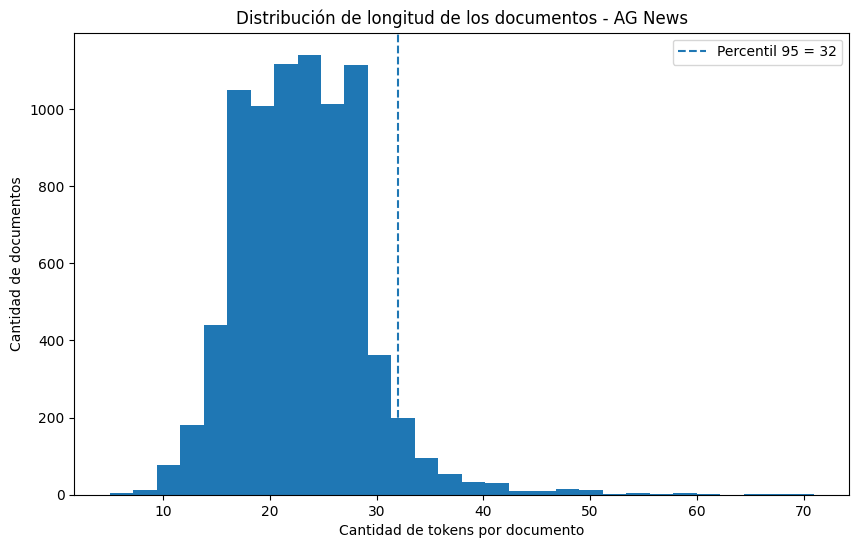

In [32]:
plt.figure(figsize=(10, 6))

plt.hist(train_df["token_count"], bins=30)

plt.axvline(
    percentil_95,
    linestyle="--",
    label=f"Percentil 95 = {percentil_95:.0f}"
)

plt.xlabel("Cantidad de tokens por documento")
plt.ylabel("Cantidad de documentos")
plt.title("Distribución de longitud de los documentos - AG News")
plt.legend()
plt.show()

**Top 50 palabras**

In [33]:
from collections import Counter

all_tokens = [
    token
    for tokens in train_df["tokens"]
    for token in tokens
]

word_freq = Counter(all_tokens)

top_50 = word_freq.most_common(50)

top_50

[('new', 1433),
 ('ap', 1117),
 ('year', 969),
 ('reuters', 731),
 ('company', 651),
 ('win', 620),
 ('world', 609),
 ('game', 553),
 ('report', 551),
 ('oil', 519),
 ('monday', 518),
 ('wednesday', 505),
 ('thursday', 502),
 ('tuesday', 495),
 ('friday', 480),
 ('week', 473),
 ('price', 465),
 ('million', 461),
 ('inc', 452),
 ('time', 448),
 ('microsoft', 446),
 ('plan', 441),
 ('iraq', 441),
 ('yesterday', 424),
 ('york', 419),
 ('day', 411),
 ('president', 409),
 ('lead', 408),
 ('kill', 403),
 ('high', 401),
 ('reuter', 392),
 ('official', 365),
 ('open', 358),
 ('government', 354),
 ('security', 354),
 ('season', 347),
 ('corp', 341),
 ('group', 341),
 ('rise', 334),
 ('team', 333),
 ('united', 333),
 ('people', 332),
 ('end', 330),
 ('month', 329),
 ('share', 328),
 ('state', 325),
 ('stock', 317),
 ('market', 316),
 ('service', 315),
 ('sunday', 315)]

In [34]:
top_50_df = pd.DataFrame(
    top_50,
    columns=["Palabra", "Frecuencia"]
)

top_50_df

,Palabra,Frecuencia
0,new,1433
1,ap,1117
2,year,969
3,reuters,731
4,company,651
5,win,620
6,world,609
7,game,553
8,report,551
9,oil,519


**Bigramas y Tigramas**

**20 Bigramas mas frecuentes**

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bigram = CountVectorizer(
    ngram_range=(2, 2)
)

X_bigram = vectorizer_bigram.fit_transform(train_df["text_clean"])

bigram_frequencies = X_bigram.sum(axis=0)

bigrams = [
    (word, bigram_frequencies[0, idx])
    for word, idx in vectorizer_bigram.vocabulary_.items()
]

bigrams = sorted(
    bigrams,
    key=lambda x: x[1],
    reverse=True
)

top_20_bigrams = bigrams[:20]

top_20_bigrams

[('ap ap', np.int64(529)),
 ('new york', np.int64(419)),
 ('oil price', np.int64(197)),
 ('united states', np.int64(167)),
 ('york reuters', np.int64(151)),
 ('prime minister', np.int64(139)),
 ('afp afp', np.int64(134)),
 ('reuter reuter', np.int64(101)),
 ('red sox', np.int64(98)),
 ('san francisco', np.int64(96)),
 ('los angeles', np.int64(96)),
 ('president bush', np.int64(93)),
 ('year old', np.int64(88)),
 ('reuters reuters', np.int64(87)),
 ('mobile phone', np.int64(72)),
 ('wall street', np.int64(71)),
 ('microsoft corp', np.int64(70)),
 ('quote profile', np.int64(69)),
 ('profile research', np.int64(69)),
 ('world cup', np.int64(69))]

In [36]:
import pandas as pd

df_bigrams = pd.DataFrame(
    top_20_bigrams,
    columns=["Bigram", "Frequency"]
)

df_bigrams

,Bigram,Frequency
0,ap ap,529
1,new york,419
2,oil price,197
3,united states,167
4,york reuters,151
5,prime minister,139
6,afp afp,134
7,reuter reuter,101
8,red sox,98
9,san francisco,96


**20 Trigramas más frecuentes**

In [37]:
vectorizer_trigram = CountVectorizer(
    ngram_range=(3, 3)
)

X_trigram = vectorizer_trigram.fit_transform(train_df["text_clean"])

trigram_frequencies = X_trigram.sum(axis=0)

trigrams = [
    (word, trigram_frequencies[0, idx])
    for word, idx in vectorizer_trigram.vocabulary_.items()
]

trigrams = sorted(
    trigrams,
    key=lambda x: x[1],
    reverse=True
)

top_20_trigrams = trigrams[:20]

df_trigrams = pd.DataFrame(
    top_20_trigrams,
    columns=["Trigram", "Frequency"]
)

df_trigrams

,Trigram,Frequency
0,new york reuters,151
1,quote profile research,69
2,boston red sox,37
3,high oil price,27
4,canadian press canadian,26
5,press canadian press,26
6,york reuters stock,26
7,prime minister ariel,26
8,minister ariel sharon,25
9,san francisco reuters,23


**Stopwords**

In [38]:
top_50_words = [word for word, freq in contador_tokens.most_common(50)]

stopwords_top_50 = [
    word for word in top_50_words
    if nlp.vocab[word].is_stop
]

print("Stopwords dentro del Top 50:", len(stopwords_top_50))
print(stopwords_top_50)

Stopwords dentro del Top 50: 0
[]


De las 50 palabras más frecuentes, solo 2 (say y take) fueron identificadas como stopwords por SpaCy. Esto indica que la estrategia de filtrado aplicada durante el preprocesamiento redujo considerablemente la presencia de palabras funcionales, conservando principalmente términos con contenido informativo para la clasificación.

**Distribución de Clases**

In [39]:
train_df["label"].value_counts()

,count
label,
Sci_Tech,2000
Business,2000
Sports,2000
World,2000


La distribución de clases presenta un balance perfecto entre las cuatro categorías del corpus: Sci_Tech, Business, Sports y World cuentan con 2.000 documentos cada una, representando cada clase el 25 % del conjunto de entrenamiento. Esta distribución equilibrada constituye una condición favorable para el modelado posterior, ya que no se observa un desbalance que pueda introducir sesgos hacia alguna categoría.

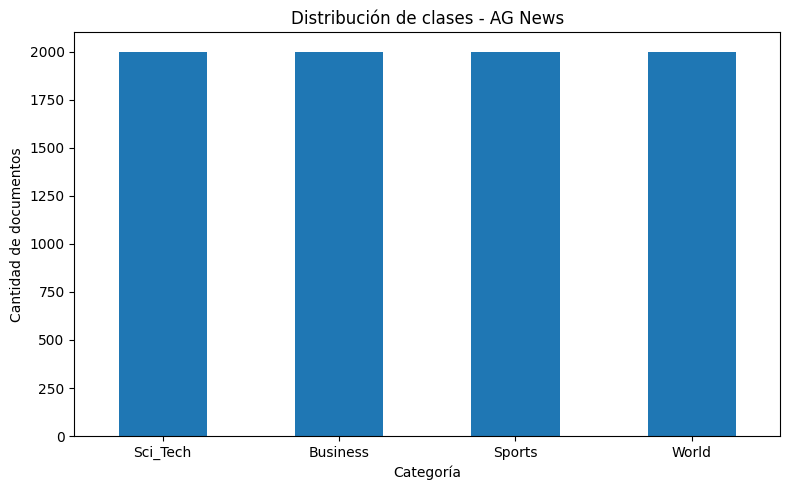

In [40]:
import matplotlib.pyplot as plt

class_counts = train_df["label"].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Distribución de clases - AG News")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de documentos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Análisis de señales temáticas y de fuente**

Además del análisis de los n-gramas más frecuentes, se revisaron algunos términos asociados a agencias de noticias, como `reuters`, `afp` y `ap`, con el objetivo de determinar si funcionan como señales temáticas o si principalmente reflejan la fuente periodística.

Los resultados muestran que estos términos presentan asociaciones diferentes con las categorías del corpus. `reuters` aparece en 641 documentos y presenta mayor frecuencia en `Business` (312 documentos), aunque también está presente en las restantes categorías. `afp` aparece en 177 documentos y presenta una fuerte concentración en `World` (132 documentos). Por su parte, `ap` aparece en 585 documentos y se concentra principalmente en `Sports` (213), `World` (203) y `Sci_Tech` (150), con una presencia considerablemente menor en `Business` (19).

A partir de esta revisión, se considera que estos términos no constituyen señales temáticas propiamente dichas, sino que pueden actuar como **señales indirectas asociadas a la fuente periodística**. Su presencia puede facilitar la predicción de determinadas categorías debido a las asociaciones existentes en este corpus entre ciertas agencias y determinados tipos de noticias.

Por este motivo, no se eliminaron estos términos del preprocesamiento, pero se documenta su posible influencia como característica predictiva. Esta consideración resulta relevante al interpretar el desempeño del clasificador, ya que parte de la capacidad predictiva podría estar relacionada con características de la fuente además del contenido temático de las noticias.


**Verificación de frecuencia de trigramas**

Se revisó específicamente la frecuencia del trigram `minister tony blair`, debido a que en un análisis preliminar se había reportado una frecuencia de 1.

Al recalcular la frecuencia sobre los tokens finales del corpus, utilizando un conteo de ocurrencias de cada trigram dentro de los documentos, se obtuvo una frecuencia de **17**. Además, se identificaron **17 documentos** que contienen dicho trigram.

Esto indica que el valor de frecuencia 17 es consistente con el criterio de conteo utilizado. En los documentos analizados, el trigram aparece una vez por documento y presenta una fuerte asociación con la categoría `World`: 16 de los 17 documentos pertenecen a esta categoría, mientras que uno pertenece a `Sci_Tech`.

Por lo tanto, `minister tony blair` puede considerarse un n-gram con capacidad de aportar información relacionada con la categoría, aunque su aparición también está vinculada a un conjunto específico de noticias sobre política británica y relaciones internacionales.


**Experimentación con TF-IDF**

Vectorización TF-IDF

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

Ajustar TF-IDF solamente sobre train

In [42]:
X_train_tfidf = vectorizer.fit_transform(train_df["text_clean"])
X_test_tfidf = vectorizer.transform(test_df["text_clean"])

In [43]:
print("Dimensiones X_train:", X_train_tfidf.shape)
print("Dimensiones X_test:", X_test_tfidf.shape)

Dimensiones X_train: (8000, 10000)
Dimensiones X_test: (2000, 10000)


In [44]:
print("Cantidad de características:", len(vectorizer.get_feature_names_out()))

Cantidad de características: 10000


Configuración A — Unigramas, 5.000 características

In [45]:
vectorizer_a = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1)
)

X_train_a = vectorizer_a.fit_transform(train_df["text_clean"])
X_test_a = vectorizer_a.transform(test_df["text_clean"])

print("Configuración A")
print("X_train:", X_train_a.shape)
print("X_test:", X_test_a.shape)

Configuración A
X_train: (8000, 5000)
X_test: (2000, 5000)


Configuración B — Unigramas + bigramas, 10.000 características

In [46]:
vectorizer_b = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_b = vectorizer_b.fit_transform(train_df["text_clean"])
X_test_b = vectorizer_b.transform(test_df["text_clean"])

print("Configuración B")
print("X_train:", X_train_b.shape)
print("X_test:", X_test_b.shape)

Configuración B
X_train: (8000, 10000)
X_test: (2000, 10000)


Configuración C — Unigramas + bigramas, 20.000 características

In [47]:
vectorizer_c = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_c = vectorizer_c.fit_transform(train_df["text_clean"])
X_test_c = vectorizer_c.transform(test_df["text_clean"])

print("Configuración C")
print("X_train:", X_train_c.shape)
print("X_test:", X_test_c.shape)

Configuración C
X_train: (8000, 20000)
X_test: (2000, 20000)


**Modelado — Clasificador supervisado**

**Regresión Logística**

Se selecciona Regresión Logística como modelo baseline debido a su buen desempeño en problemas de clasificación de texto multiclase y su capacidad para trabajar eficientemente con matrices dispersas, como las generadas por TF-IDF. Además, permite establecer una referencia sólida para comparar posteriormente con modelos de Deep Learning.

In [48]:
# Importar modelo

from sklearn.linear_model import LogisticRegression

In [49]:
# Configuración A

model_a = LogisticRegression(max_iter=1000)

model_a.fit(X_train_a, train_df["label"])

y_pred_a = model_a.predict(X_test_a)

In [50]:
# Configuración B

model_b = LogisticRegression(max_iter=1000)

model_b.fit(X_train_b, train_df["label"])

y_pred_b = model_b.predict(X_test_b)

In [51]:
# Configuración C

model_c = LogisticRegression(max_iter=1000)

model_c.fit(X_train_c, train_df["label"])

y_pred_c = model_c.predict(X_test_c)

In [52]:
# Comparación de Resultados

from sklearn.metrics import accuracy_score, f1_score

resultados = []

for nombre, y_pred in [
    ("A - 5.000 unigramas", y_pred_a),
    ("B - 10.000 unigramas + bigramas", y_pred_b),
    ("C - 20.000 unigramas + bigramas", y_pred_c)
]:
    resultados.append({
        "Configuración": nombre,
        "Accuracy": accuracy_score(test_df["label"], y_pred),
        "F1 Macro": f1_score(test_df["label"], y_pred, average="macro")
    })

resultados_df = pd.DataFrame(resultados)

display(resultados_df)

,Configuración,Accuracy,F1 Macro
0,A - 5.000 unigramas,0.893,0.892965
1,B - 10.000 unigramas + bigramas,0.894,0.893938
2,C - 20.000 unigramas + bigramas,0.895,0.894964


Se seleccionó la configuración C, con max_features=20.000 y ngram_range=(1,2), debido a que obtuvo el mejor desempeño entre las alternativas evaluadas, alcanzando un Accuracy de 89,5 % y un F1 Macro de 0,8949.

La incorporación de bigramas y un vocabulario más amplio produjo una mejora progresiva respecto de las configuraciones con menor cantidad de características. Esto indica que, para este corpus, ampliar el vocabulario e incorporar relaciones entre pares de palabras aporta información útil para la clasificación.

**Classification Report**

In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    test_df["label"],
    y_pred_c
))

              precision    recall  f1-score   support

    Business       0.85      0.86      0.85       500
    Sci_Tech       0.87      0.87      0.87       500
      Sports       0.95      0.97      0.96       500
       World       0.91      0.89      0.90       500

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.89      2000
weighted avg       0.90      0.90      0.89      2000



El modelo alcanzó un **Accuracy del 90 %**, lo que significa que clasificó correctamente aproximadamente 9 de cada 10 noticias del conjunto de prueba.

La categoría con mejor desempeño fue **Sports**, con un **F1-score de 0,96** y un **recall de 0,97**. Esto indica que las noticias deportivas presentan características léxicas bastante diferenciadas respecto de las demás categorías, facilitando su identificación.

Por otro lado, **Business** fue la categoría con mayor dificultad, con un **F1-score de 0,85**. **Sci_Tech** también presentó un desempeño ligeramente inferior al resto, con un **F1-score de 0,87**. Una posible explicación es que estas categorías pueden presentar mayor similitud en el vocabulario utilizado, lo que dificulta la diferenciación entre determinados tipos de noticias.

**World** obtuvo un resultado intermedio, con un **F1-score de 0,90**.

Además, como las cuatro categorías tienen exactamente **500 documentos** en el conjunto de prueba, la evaluación se realiza sobre un conjunto perfectamente balanceado. Por este motivo, el **Accuracy y el F1 Macro presentan valores muy similares**, sin que una categoría tenga un peso mayor que otra en la evaluación global.


**Matriz de confusión**

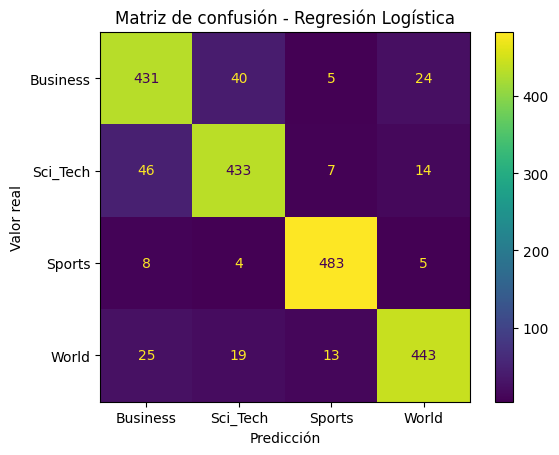

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df["label"], y_pred_c)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_c.classes_
)

disp.plot()

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

La matriz de confusión muestra un buen desempeño general del modelo, con una identificación particularmente precisa de la categoría **Sports**, donde **483 de 500 noticias** fueron correctamente clasificadas.

Las principales dificultades se observan entre **Business y Sci_Tech**, con **40 noticias de Business clasificadas como Sci_Tech** y **46 noticias de Sci_Tech clasificadas como Business**. Esta confusión puede estar relacionada con la similitud del vocabulario utilizado en noticias vinculadas con empresas, tecnología, mercados e innovación.

La categoría **World** también presenta algunas confusiones con **Business**, aunque en menor medida: **25 noticias de World fueron clasificadas como Business**, mientras que **24 noticias de Business fueron clasificadas como World**.

En términos generales, la matriz confirma que el modelo logra una buena separación entre las categorías, especialmente en **Sports**, mientras que **Business y Sci_Tech** representan el principal desafío de clasificación.

***Conclusiones***

El pipeline desarrollado permitió realizar el preprocesamiento, análisis y clasificación del corpus AG News mediante técnicas de procesamiento de lenguaje natural. Se aplicaron procedimientos de limpieza y normalización del texto, lematización, eliminación de stopwords y representación mediante TF-IDF. Además, se analizaron diferentes características del corpus, incluyendo la longitud de los documentos, las palabras más frecuentes y los principales bigramas y trigramas.

Para la clasificación se evaluaron tres configuraciones de TF-IDF utilizando Regresión Logística como modelo baseline. La configuración seleccionada, compuesta por hasta 20.000 características y unigramas más bigramas, obtuvo el mejor desempeño, alcanzando un Accuracy de 90 % y un F1 Macro de 0,8965 sobre el conjunto de prueba.

Los resultados muestran un buen desempeño general del clasificador. La categoría Sports presentó el mejor comportamiento, mientras que las principales dificultades se observaron entre Business y Sci_Tech, donde existe mayor similitud en el vocabulario utilizado. Esta implementación establece una línea base para futuras etapas del proyecto, en las que podrá compararse su desempeño con modelos de Deep Learning.